# Text classification Spam Detection with CNN, RNN, Random Forest, SVM

## 1. Data Preprocessing

In [1]:
import tensorflow as tf
print(tf.__version__)

2.18.0


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Embedding
from tensorflow.keras.layers import LSTM, Embedding
from tensorflow.keras.models import Model
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv('spam.csv', encoding='ISO-8859-1') # encoding needed otherwise error raise, because some varchar exist

In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
# drop garbage columns
df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)

In [6]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df.shape

(5572, 2)

In [8]:
# rename columns
df.columns = ['labels', 'data']

In [9]:
df.head()

,labels,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
# create binary labels (0 and 1)
df['b_labels'] = df['labels'].map({'ham': 0, 'spam': 1}) # create new column as 'b_labels'
y = df['b_labels'].values

In [11]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [12]:
df

,labels,data,b_labels
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,1
5568,ham,Will Ì_ b going to esplanade fr home?,0
5569,ham,"Pity, * was in mood for that. So...any other s...",0
5570,ham,The guy did some bitching but I acted like i'd...,0


In [13]:
# split the data
x_train, x_test, y_train, y_test = train_test_split(df['data'], y, test_size=0.33)
#x_train, x_test, y_train, y_test = train_test_split(df['data'], y, test_size=0.3,random_state=0,shuffle=True)

In [14]:
# Convert sentences to sequences
max_vocab_size = 20000
tokenizer = Tokenizer(num_words=max_vocab_size)
tokenizer.fit_on_texts(x_train)
sequences_train = tokenizer.texts_to_sequences(x_train)
sequences_test = tokenizer.texts_to_sequences(x_test)

In [15]:
x_train

4108                     I want to lick your pussy now...
3161    I can't describe how lucky you are that I'm ac...
483     Thank you baby! I cant wait to taste the real ...
4851                               I liked your new house
4417                           When you get free, call me
                              ...                        
87      Yes I started to send requests to make it but ...
1690    Sunshine Quiz Wkly Q! Win a top Sony DVD playe...
4525    I want some cock! My hubby's away, I need a re...
1798       That one week leave i put know that time. Why.
1761    Got ur mail Dileep.thank you so muchand look f...
Name: data, Length: 3733, dtype: object

In [16]:
sequences_train[0]

[1, 69, 2, 1782, 13, 1088, 19]

In [17]:
len(sequences_train[0])

7

In [18]:
len(sequences_train[1])

13

In [19]:
# Check word index mapping (to check the number of words in vocabulary)
word2idx = tokenizer.word_index
V = len(word2idx)
print('Total number of unique tokens are: %s' % V)

Total number of unique tokens are: 7101


In [20]:
# pad sequences (to get  N x T matrix)
data_train = pad_sequences(sequences_train)
print('Shape of data train tensor:', data_train.shape)

# N: number of samples and T: Number of time steps

Shape of data train tensor: (3733, 98)


In [21]:
data_train.shape

(3733, 98)

In [22]:
data_train

array([[   0,    0,    0, ...,   13, 1088,   19],
       [   0,    0,    0, ..., 1089,   75, 1090],
       [   0,    0,    0, ...,    5,  343,  227],
       ...,
       [   0,    0,    0, ..., 7095, 7096, 7097],
       [   0,    0,    0, ...,   18,   61,  187],
       [   0,    0,    0, ...,   71, 1411,  105]], dtype=int32)

In [23]:
# set the value of T to get sequence length
T = data_train.shape[1]

In [24]:
print(T)

98


In [25]:
# pad the test set
data_test = pad_sequences(sequences_test, maxlen=T)
# maxlen = T, to truncate longer sentences in test set
print('Shape of data test tensor:', data_test.shape)

Shape of data test tensor: (1839, 98)


## 2. Building the CNN model

In [26]:
# Create the model

# Choose embedding dimensionality
D = 20  # this is a hyper parameter, we can choose any word vector size that we want

# Input layer
i = Input(shape=(T,))  # input layer takes in sequences of integers, so shape is T

# Embedding layer
x = Embedding(V + 1, D)(i) # This takes in sequences of integers and returns sequences of word vectors
# This will be an N * T * D array
# we want size of embedding to (V + 1) x D, because first word index starts from 1 and not 0

#  First CNN layer
x = Conv1D(32, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)

# Second CNN layer
x = Conv1D(64, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)

# Third CNN layer
x = Conv1D(128, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)

# Dense layer
x = Dense(1, activation='sigmoid')(x)

model = Model(i, x)

In [27]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [28]:
# Train the model
r = model.fit(x=data_train, y=y_train, epochs=5, validation_data=(data_test, y_test))

Epoch 1/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8732 - loss: 0.4231 - val_accuracy: 0.9331 - val_loss: 0.1618
Epoch 2/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9699 - loss: 0.0955 - val_accuracy: 0.9788 - val_loss: 0.0646
Epoch 3/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9929 - loss: 0.0249 - val_accuracy: 0.9799 - val_loss: 0.0555
Epoch 4/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9986 - loss: 0.0053 - val_accuracy: 0.9831 - val_loss: 0.0518
Epoch 5/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9848 - val_loss: 0.0596


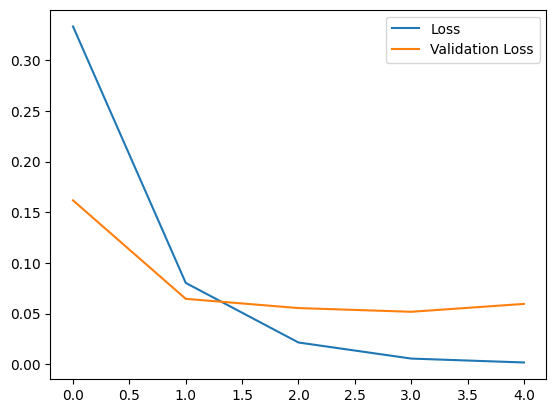

In [29]:
# Loss per iteration
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='Loss')
plt.plot(r.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

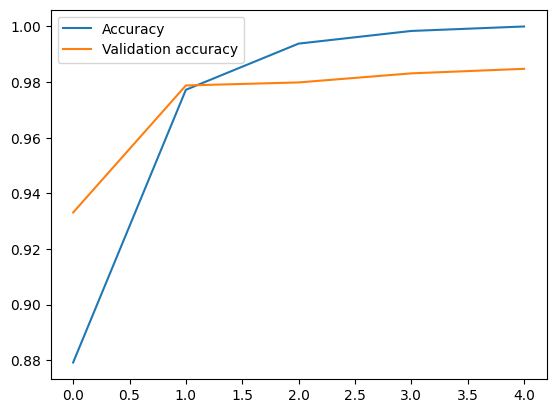

In [30]:
# Accuracy per iteration
plt.plot(r.history['accuracy'], label='Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation accuracy')
plt.legend()
plt.show()

## 3. Building the RNN model

In [31]:
# Choose embedding dimensionality
D = 20  # this is a hyper parameter, we can choose any word vector size that we want

# Hidden state vectorsize (dimensionality)
M = 15

# Input layer
i = Input(shape=(T,))  # input layer takes in sequences of integers, so shape is T

# Embedding layer
x = Embedding(V + 1, D)(i) # This takes in sequences of integers and returns sequences of word vectors
# This will be an N * T * D array
# we want size of embedding to (V + 1) x D, because first word index starts from 1 and not 0

# LSTM layer
x = LSTM(M, return_sequences=True)(x)
x = GlobalMaxPooling1D()(x)

# Dense layer
x = Dense(1, activation='sigmoid')(x)
# it is an binary classification problem, so we are using activation function ='sigmoid'

model = Model(i, x)


In [32]:
# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [33]:
# Train the model
r = model.fit(x=data_train, y=y_train, epochs=10, validation_data=(data_test, y_test))

Epoch 1/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8288 - loss: 0.5284 - val_accuracy: 0.8668 - val_loss: 0.3080
Epoch 2/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8746 - loss: 0.2465 - val_accuracy: 0.9755 - val_loss: 0.1376
Epoch 3/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.9878 - loss: 0.0974 - val_accuracy: 0.9663 - val_loss: 0.1178
Epoch 4/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.9899 - loss: 0.0595 - val_accuracy: 0.9853 - val_loss: 0.0701
Epoch 5/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9952 - loss: 0.0318 - val_accuracy: 0.9864 - val_loss: 0.0587
Epoch 6/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9966 - loss: 0.0209 - val_accuracy: 0.9875 - val_loss: 0.0591
Epoch 7/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9982 - loss: 0.0152 - val_accuracy: 0.9869 - val_loss: 0.0587
Epoch 8/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9994 - loss: 0.0080 - val_accu

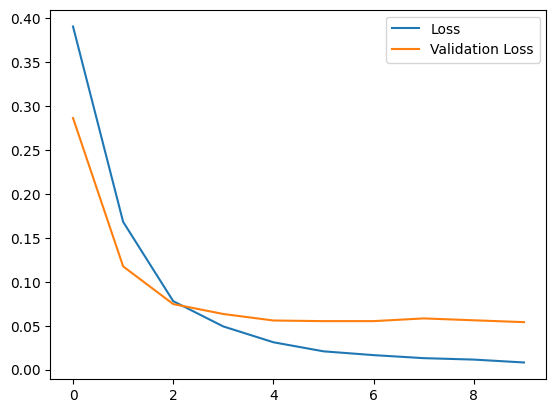

In [35]:
# Loss per iteration
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='Loss')
plt.plot(r.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

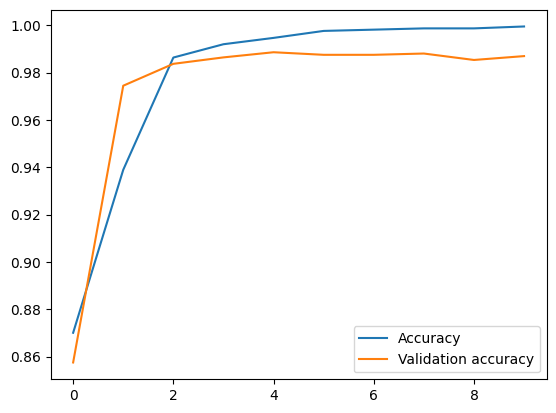

In [36]:
# Accuracy per iteration
plt.plot(r.history['accuracy'], label='Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation accuracy')
plt.legend()
plt.show()

## 4. Building the Random Forest model 

In [38]:
classifier = Pipeline([('tfidf',TfidfVectorizer()),('classifier',RandomForestClassifier(n_estimators=100))])

In [41]:
classifier.fit(x_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('classifier', RandomForestClassifier())])

In [42]:
y_pred = classifier.predict(x_test)

In [43]:
# confusion_matrix
confusion_matrix(y_test, y_pred)

array([[1594,    0],
       [  54,  191]])

In [45]:
# classification_report
print(classification_report(y_test, y_pred))
# we are getting almost 97% accuracy

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1594
           1       1.00      0.78      0.88       245

    accuracy                           0.97      1839
   macro avg       0.98      0.89      0.93      1839
weighted avg       0.97      0.97      0.97      1839



In [47]:
accuracy_score(y_test, y_pred)
# 97% accuracy

0.9706362153344209

In [49]:
test1 = ['Hello, You are learning natural Language Processing']
test2 = ['Hope you are doing good and learning new things !']
test3 = ['Congratulations, You won a lottery ticket worth $1 Million ! To claim call on 446677']

In [50]:
print(classifier.predict(test1))
print(classifier.predict(test2))
print(classifier.predict(test3))

[0]
[0]
[0]


In [103]:
#ham-0
#spam-1

## 4. Building the SVM

In [51]:
svm = Pipeline([('tfidf',TfidfVectorizer()),('classifier',SVC(C=100,gamma='auto'))])

In [52]:
svm.fit(x_train,y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('classifier', SVC(C=100, gamma='auto'))])

In [53]:
y_pred = svm.predict(x_test)

In [54]:
y_test, y_pred

(array([1, 0, 0, ..., 1, 0, 0]), array([0, 0, 0, ..., 0, 0, 0]))

In [55]:
accuracy_score(y_test,y_pred)

0.8667754214246873

In [56]:
confusion_matrix(y_test, y_pred)

array([[1594,    0],
       [ 245,    0]])

In [57]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93      1594
           1       0.00      0.00      0.00       245

    accuracy                           0.87      1839
   macro avg       0.43      0.50      0.46      1839
weighted avg       0.75      0.87      0.80      1839



C:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [58]:
print(svm.predict(test1))
print(svm.predict(test2))
print(svm.predict(test3))

[0]
[0]
[0]
